# **Global Health Spending Landscape - Out-of-poclet**

## Load Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Out-of-pocket

###Prepare data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# load files
df_health = pd.read_csv("/content/drive/My Drive/Use/health_expense_country.csv", encoding="ISO-8859-1")
df_gdp = pd.read_csv("/content/drive/My Drive/Use/gdp_per_capita.csv", encoding="ISO-8859-1")
df_out_of_pocket = pd.read_csv('/content/drive/My Drive/Use/out-of-pocket_expenditure.csv') # Load df_out_of_pocket here


# Drop Series Code column if it exists in df_health, df_gdp, and df_out_of_pocket
if "Series Code" in df_health.columns:
    df_health = df_health.drop(columns=["Series Code"])

if "Series Code" in df_gdp.columns:
    df_gdp = df_gdp.drop(columns=["Series Code"])

if "Series Code" in df_out_of_pocket.columns:
    df_out_of_pocket = df_out_of_pocket.drop(columns=["Series Code"])


# Drop years from 2023 onwards (based on previous code)
columns_to_drop = ['2023 [YR2023]', '2024 [YR2024]']
df_health = df_health.drop(columns=columns_to_drop, errors='ignore')
df_gdp = df_gdp.drop(columns=columns_to_drop, errors='ignore')
df_out_of_pocket = df_out_of_pocket.drop(columns=columns_to_drop, errors='ignore')


# Drop rows where 'Series Name' is 'Population, total' in df_gdp and df_out_of_pocket
df_gdp = df_gdp[df_gdp['Series Name'] != 'Population, total']
df_out_of_pocket = df_out_of_pocket[df_out_of_pocket['Series Name'] != 'Population, total']


# Drop rows where 'Region' or 'IncomeGroup' is '0' or '#N/A' in df_health
df_health = df_health[~df_health['Region'].isin(['0', '#N/A'])]
df_health = df_health[~df_health['IncomeGroup'].isin(['0', '#N/A'])]
df_health = df_health[df_health['Country Name'] != 'Not classified']


# Drop rows in df_out_of_pocket where '2022 [YR2022]' is '..' or not a valid number
# Convert the column to numeric, coercing errors to NaN, then drop rows with NaN
if '2022 [YR2022]' in df_out_of_pocket.columns:
    df_out_of_pocket['2022 [YR2022]'] = pd.to_numeric(df_out_of_pocket['2022 [YR2022]'], errors='coerce')
    df_out_of_pocket.dropna(subset=['2022 [YR2022]'], inplace=True)


# Display the number of rows and columns after dropping
print(f"Shape of df_health after cleaning: {df_health.shape}")
print(f"Shape of df_gdp after cleaning: {df_gdp.shape}")
print(f"Shape of df_out_of_pocket after cleaning: {df_out_of_pocket.shape}")


# แสดงผลเพื่อเช็ค
print("health expenditure after cleaning")
display(df_health.head())

print("\nGDP after cleaning")
display(df_gdp.head())

print("\nOut-of-pocket after cleaning")
display(df_out_of_pocket.head())

Shape of df_health after cleaning: (215, 18)
Shape of df_gdp after cleaning: (266, 16)
Shape of df_out_of_pocket after cleaning: (715, 16)
health expenditure after cleaning


,Country Name,Country Code,Region,IncomeGroup,Series Name,2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022]
1,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income,Current health expenditure per capita (current...,46.42438889,52.18721771,52.45247269,56.16043472,60.04951096,59.91960526,61.37234497,66.82388306,71.22509003,74.0642395,80.0892334,81.52112579,80.6516037
4,Albania,ALB,Europe & Central Asia,Upper middle income,Current health expenditure per capita (current...,253.9824677,273.7529297,260.683197,276.0765686,293.1267395,253.9334717,275.4367676,295.523468,349.2112732,366.3401489,396.1747742,465.5704346,414.3502502
5,Algeria,DZA,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income,Current health expenditure per capita (current...,227.9539642,285.5020752,340.0913391,337.5736084,366.5867004,296.7682495,265.5343933,270.9326172,271.5377808,242.0700226,211.0727692,208.526825,179.6968842
6,American Samoa,ASM,East Asia & Pacific,High income,Current health expenditure per capita (current...,..,..,..,..,..,..,..,..,..,..,..,..,..
7,Andorra,AND,Europe & Central Asia,High income,Current health expenditure per capita (current...,3277.785156,3550.908203,2785.188965,2887.025879,3001.196045,2672.264648,2769.152832,2876.178711,3158.136475,3021.432617,3282.817383,3535.989746,3192.315674



GDP after cleaning


,Country Name,Country Code,Series Name,2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022]
0,World,WLD,GDP per capita (current US$),9530.010809,10471.53643,10570.75881,10744.62036,10911.80674,10175.40942,10221.36598,10765.26622,11326.9339,11376.82334,10963.17564,12418.56592,12819.74484
2,Afghanistan,AFG,GDP per capita (current US$),560.6215055,606.6946763,651.4171345,637.0870991,625.0549418,565.5697304,522.0822156,525.4697709,491.3372214,496.6025043,510.7870634,356.4962141,357.2611528
4,Africa Eastern and Southern,AFE,GDP per capita (current US$),1601.727651,1735.584923,1702.9691,1673.221102,1656.167709,1479.61526,1329.807285,1520.212231,1538.901679,1493.817938,1344.10321,1522.393346,1628.318944
6,Africa Western and Central,AFW,GDP per capita (current US$),1663.966937,1844.198595,1941.369556,2131.662067,2221.010665,1860.727694,1630.039447,1574.23056,1720.14028,1798.340685,1680.039332,1765.954788,1796.668633
8,Albania,ALB,GDP per capita (current US$),4149.144699,4465.709143,4222.347099,4420.23462,4602.230514,3981.726623,4168.375445,4614.047969,5365.488802,5460.430509,5370.7775,6413.282808,6846.426694



Out-of-pocket after cleaning


,Country Name,Country Code,Series Name,2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022]
0,World,WLD,Out-of-pocket expenditure per capita (current ...,165.879113,180.4107555,184.1944618,188.5431477,189.4074585,178.8031567,179.7271415,185.0957856,192.6736212,194.559298,189.5899208,212.3420512,213.401075
1,World,WLD,Out-of-pocket expenditure (% of current health...,18.42721845,18.51808859,18.74484354,18.98893808,18.64599224,18.35470316,18.11641472,17.99250958,18.02748316,17.90105256,16.32785547,17.00043192,17.233738
2,World,WLD,"Out-of-pocket expenditure per capita, PPP (cur...",229.2992209,236.9497698,249.2702984,262.1639575,264.9712222,271.1095968,279.4437622,281.6058337,292.7240792,305.1018825,303.8685294,330.2554688,352.302630
3,Afghanistan,AFG,Out-of-pocket expenditure per capita (current ...,36.67371379,38.22983107,39.06985734,40.46239344,43.86972469,46.96636207,46.62723365,50.44039361,54.28991757,56.89493912,59.91792599,62.94576762,62.864813
4,Afghanistan,AFG,Out-of-pocket expenditure (% of current health...,78.9966507,73.25517273,74.48620605,72.04785919,73.05592346,78.3822937,75.97433472,75.48258209,76.22302246,76.818367,74.81396484,77.21405029,77.946152


###Avg. Out-of-pocket Share of Health Expenditure, by Income Group (%) (Year 2022)

Preview of the merged DataFrame (df_final):


,Country Name,Country Code,Region,IncomeGroup,Year,Health_Expenditure_Value,Out_of_Pocket_Value,GDP_Value,OOP_Percentage
0,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income,2010,46.424389,36.673714,560.621506,78.996654
1,Albania,ALB,Europe & Central Asia,Upper middle income,2010,253.982468,152.305170,4149.144699,59.966805
2,Algeria,DZA,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income,2010,227.953964,65.838673,4912.785855,28.882443
3,Andorra,AND,Europe & Central Asia,High income,2010,3277.785156,381.480586,42746.830950,11.638365
4,Angola,AGO,Sub-Saharan Africa,Lower middle income,2010,96.951973,18.754154,3597.342932,19.343757


Preview of DataFrame used for plotting:


,IncomeGroup,OOP_Percentage
0,High income,19.340606
3,Upper middle income,32.006418
2,Lower middle income,35.137779
1,Low income,42.439600


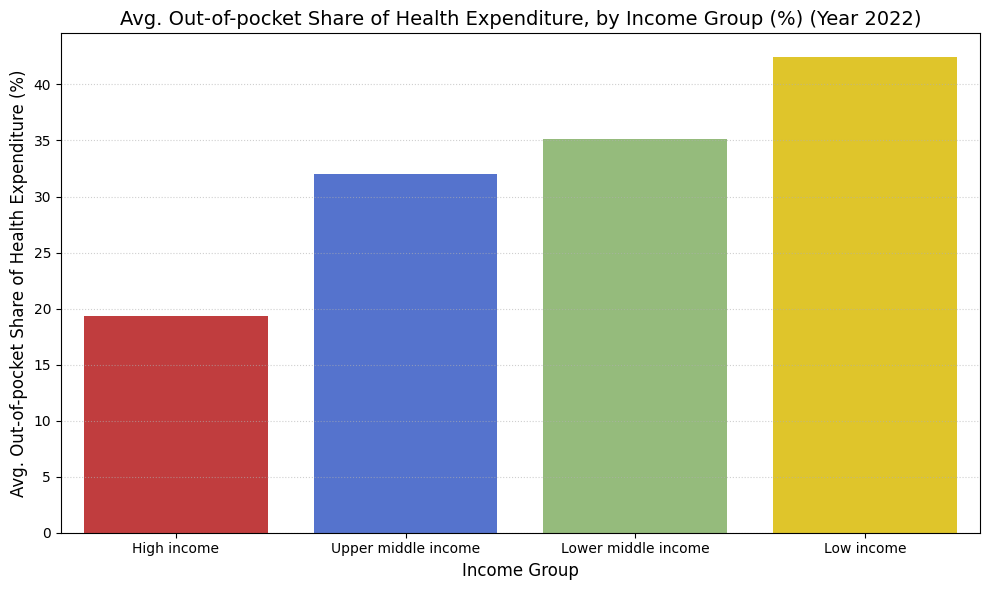

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Cleaning and Reshaping
def prepare_data(df, series_name_to_filter, value_name):
    """
    Cleans and reshapes a single dataframe from wide to long format.
    """
    # Identify the year columns
    year_cols = [col for col in df.columns if '[YR' in col]

    # Define the columns that identify each unique entry
    # 'Series Code' is dropped in the previous cell, so it's not included in id_vars here
    id_vars = ['Country Name', 'Country Code', 'Series Name']
    # Include Region and IncomeGroup in id_vars if they exist in the dataframe
    if 'Region' in df.columns and 'IncomeGroup' in df.columns:
        id_vars.extend(['Region', 'IncomeGroup'])


    # Convert from 'wide' to 'long' format
    df_long = pd.melt(df, id_vars=id_vars, value_vars=year_cols, var_name='Year', value_name=value_name)

    # Extract the year and convert to integer
    df_long['Year'] = df_long['Year'].str.extract(r'(\d{4})').astype(int)

    # Filter for the specific metric
    df_filtered = df_long[df_long['Series Name'] == series_name_to_filter].copy()

    # Convert the value column to numeric, coercing errors to NaN
    df_filtered[value_name] = pd.to_numeric(df_filtered[value_name], errors='coerce')

    # Drop rows with missing values
    df_filtered.dropna(subset=[value_name], inplace=True)

    # Drop 'Series Name' as it's no longer needed after filtering
    cols_to_drop = ['Series Name']


    return df_filtered.drop(columns=cols_to_drop)

try:
    df_oop_clean = prepare_data(df_out_of_pocket, 'Out-of-pocket expenditure per capita (current US$)', 'Out_of_Pocket_Value')
    df_gdp_clean = prepare_data(df_gdp, 'GDP per capita (current US$)', 'GDP_Value')
    df_health_clean = prepare_data(df_health, 'Current health expenditure per capita (current US$)', 'Health_Expenditure_Value') # Use df_health from previous cell

except NameError:
    print("Error: DataFrames (df_health, df_gdp, df_out_of_pocket) not found. Please run the previous cell (JFpr7PrLNDCv) first.")



# Merge the datasets
# Start by merging health expense and out-of-pocket data, keep Region and IncomeGroup from health expense
df_merged = pd.merge(df_health_clean, df_oop_clean.drop(columns=['Region', 'IncomeGroup'], errors='ignore'), on=['Country Code', 'Year', 'Country Name'], how='inner')

# merge with the GDP data, keep Region and IncomeGroup from the previous merge
df_final = pd.merge(df_merged, df_gdp_clean.drop(columns=['Region', 'IncomeGroup'], errors='ignore'), on=['Country Code', 'Year', 'Country Name'], how='inner')

# Drop any final rows with missing values
df_final.dropna(inplace=True)

# Calculate the out-of-pocket percentage of total health expenditure using np.divide
# Use where to avoid division by zero and assign 0 in those cases
df_final['OOP_Percentage'] = np.divide(df_final['Out_of_Pocket_Value'], df_final['Health_Expenditure_Value'],
                                       out=np.zeros_like(df_final['Out_of_Pocket_Value']),
                                       where=(df_final['Health_Expenditure_Value'] != 0)) * 100


# Display preview of the merged DataFrame
print("Preview of the merged DataFrame (df_final):")
display(df_final.head())


# Select the year 2022 for plotting
year_to_analyze = 2022
df_year = df_final[df_final['Year'] == year_to_analyze].copy()

# Exclude aggregates and income groups with few data points
df_year_filtered = df_year[~df_year['IncomeGroup'].isin(['0', 'Not classified'])].copy()

# Calculate the average OOP Percentage for each Income Group
average_oop_by_income = df_year_filtered.groupby('IncomeGroup')['OOP_Percentage'].mean().reset_index()

# Define the order of income groups for the plot
income_order = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']
average_oop_by_income['IncomeGroup'] = pd.Categorical(average_oop_by_income['IncomeGroup'], categories=income_order, ordered=True)
average_oop_by_income = average_oop_by_income.sort_values('IncomeGroup')

# Define custom colors for the income groups
colors = ['#d62728', '#4169E1', '#93C572', '#FDDA0D']
palette = dict(zip(income_order, colors))

# Display preview of the DataFrame used for plotting
print("Preview of DataFrame used for plotting:")
display(average_oop_by_income.head())

plt.figure(figsize=(10, 6))
sns.barplot(data=average_oop_by_income, x='IncomeGroup', y='OOP_Percentage', palette=palette, hue='IncomeGroup', legend=False) # Use the custom palette
plt.title(f'Avg. Out-of-pocket Share of Health Expenditure, by Income Group (%) (Year {year_to_analyze})', fontsize=14)
plt.xlabel('Income Group', fontsize=12)
plt.ylabel('Avg. Out-of-pocket Share of Health Expenditure (%)', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

###Distribution of Out-of-pocket Share of Health Expenditure, by Income Group (%) (Year 2022)

/tmp/ipython-input-3845119280.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_year_filtered, x='IncomeGroup', y='OOP_Percentage', order=income_order, palette=palette) # Use the custom palette and specified order


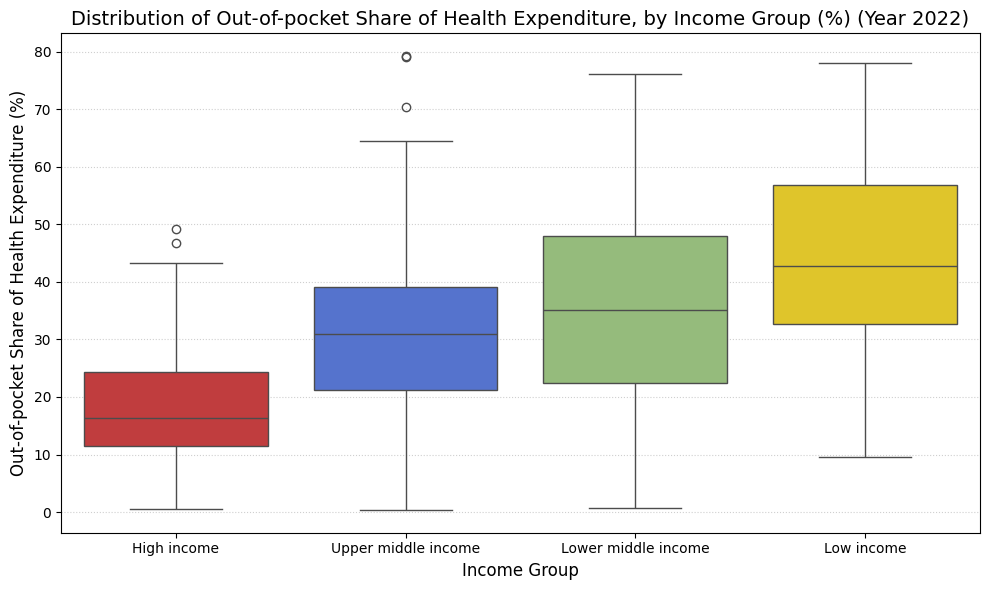

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select the year 2022 for plotting
year_to_analyze = 2022
df_year = df_final[df_final['Year'] == year_to_analyze].copy()

# Calculate the out-of-pocket percentage of total health expenditure if not already present
if 'OOP_Percentage' not in df_year.columns:
    df_year['OOP_Percentage'] = (df_year['Out_of_Pocket_Value'] / df_year['Health_Expenditure_Value']) * 100

# Exclude aggregates and income groups with few data points
df_year_filtered = df_year[~df_year['IncomeGroup'].isin(['0', 'Not classified'])].copy()

# Define the order of income groups for the plot
income_order = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']

# Define custom colors for the income groups
colors = ['#d62728', '#4169E1', '#93C572', '#FDDA0D']
palette = dict(zip(income_order, colors))


plt.figure(figsize=(10, 6))
sns.boxplot(data=df_year_filtered, x='IncomeGroup', y='OOP_Percentage', order=income_order, palette=palette) # Use the custom palette and specified order
plt.title(f'Distribution of Out-of-pocket Share of Health Expenditure, by Income Group (%) (Year {year_to_analyze})', fontsize=14)
plt.xlabel('Income Group', fontsize=12)
plt.ylabel('Out-of-pocket Share of Health Expenditure (%)', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

###Composition of Health Expenditure by Income Group (Year 2010-2022)


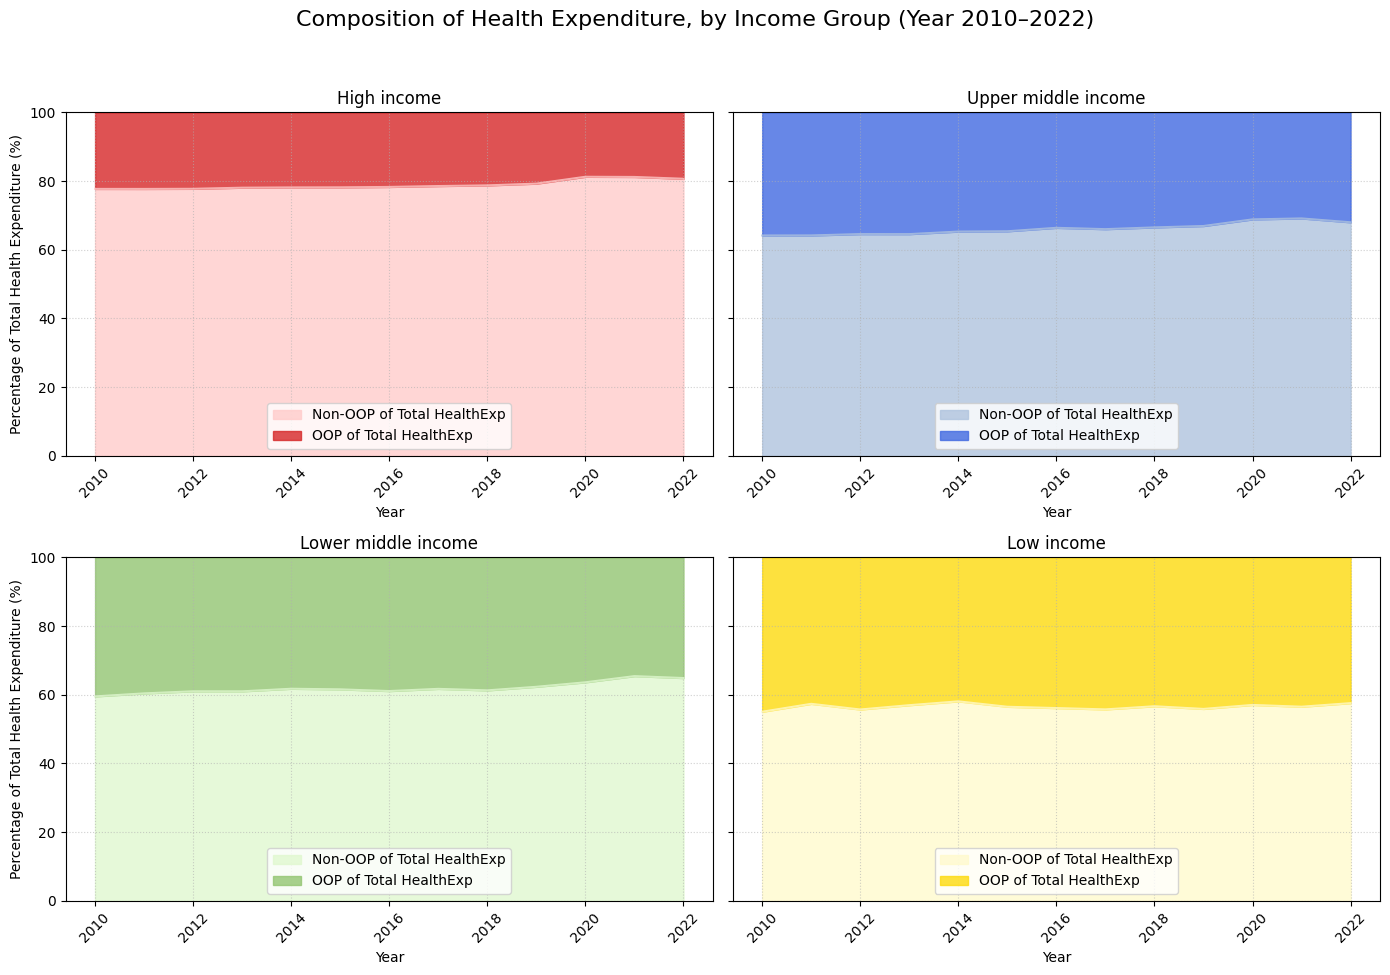

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap, to_rgba # Import necessary modules for colors
import matplotlib.ticker as ticker # Import ticker

# Calculate HealthExp per GDP and OOP per GDP over the years
df_final['HealthExp_per_GDP'] = (df_final['Health_Expenditure_Value'] / df_final['GDP_Value']) * 100
df_final['OOP_per_GDP'] = (df_final['Out_of_Pocket_Value'] / df_final['GDP_Value']) * 100

# Drop rows with NaN in the new columns (if GDP=0 or Health_Expenditure=0)
df_final.dropna(subset=['HealthExp_per_GDP', 'OOP_per_GDP', 'Health_Expenditure_Value'], inplace=True)

# Calculate Out-of-pocket expenditure as a percentage of total Health Expenditure
# Use np.divide with where to avoid division by zero and assign 0 in those cases
df_final['OOP of Total HealthExp'] = np.divide(df_final['Out_of_Pocket_Value'], df_final['Health_Expenditure_Value'],
                                       out=np.zeros_like(df_final['Out_of_Pocket_Value']),
                                       where=(df_final['Health_Expenditure_Value'] != 0)) * 100

zero_oop_count = df_final[df_final['OOP of Total HealthExp'] == 0].shape[0]

if zero_oop_count > 0:
  print("\nRows where 'OOP of Total HealthExp' is 0:")
else:
  pass

df_final['Non-OOP of Total HealthExp'] = 100 - df_final['OOP of Total HealthExp']


# Exclude aggregates and income groups with few data points
df_final_filtered = df_final[~df_final['Region'].isin(['0', 'Aggregates', 'Not classified'])].copy()
df_final_filtered = df_final_filtered[~df_final_filtered['IncomeGroup'].isin(['0', 'Not classified'])].copy()

# Exclude years from 2023 onwards
df_final_filtered = df_final_filtered[df_final_filtered['Year'] < 2023].copy()


# Group by year and income group and calculate the mean for plotting the trend
df_trend_income = df_final_filtered.groupby(['Year', 'IncomeGroup'])[['OOP of Total HealthExp', 'Non-OOP of Total HealthExp']].mean().reset_index()

# --- Create 100% Stacked Area Plots for each Income Group in Subplots ---

# Define the order of income groups for plotting
income_order = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']

# Define custom colors for the income groups (OOP part)
oop_colors = ['#d62728', '#4169E1', '#93C572', '#FDDA0D']
# Define distinct lighter colors for the Non-OOP part
non_oop_colors_distinct = ['#ffcccb', '#b0c4de', '#e0f8d0', '#fffacd'] # Lighter shades of red, blue, green, yellow


# Set up the figure and axes for subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True) # Use sharey=True for 100% stacked area plot
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Create a 100% stacked area plot for each income group in its subplot
for i, income_group in enumerate(income_order):
    df_plot_data = df_trend_income[df_trend_income['IncomeGroup'] == income_group].copy()

    if not df_plot_data.empty:
        # Pivot the data to have years as index and expenditure types as columns
        df_plot_data = df_plot_data.pivot(index='Year', columns='IncomeGroup', values=['OOP of Total HealthExp', 'Non-OOP of Total HealthExp'])

        # Flatten the column names for easier plotting
        # The column names after pivot will be tuples like ('OOP of Total HealthExp', 'High income')
        # We want to keep just the first element of the tuple for plotting
        df_plot_data.columns = [col[0] for col in df_plot_data.columns]


        # Select only the relevant columns for the stacked area plot for this income group
        df_plot_data = df_plot_data[['Non-OOP of Total HealthExp', 'OOP of Total HealthExp']] # Order for stacking

        # Define the colors for this specific income group's stacked area plot
        colors_for_plot = [non_oop_colors_distinct[i], oop_colors[i]]


        # Plot the stacked area plot on the current axis with custom colors
        df_plot_data.plot(kind='area', stacked=True, ax=axes[i], alpha=0.8, color=colors_for_plot) # Use color parameter


        # Set title and labels for the subplot
        axes[i].set_title(f'{income_group}')
        axes[i].set_xlabel('Year', fontsize=10)
        axes[i].set_ylabel('Percentage of Total Health Expenditure (%)', fontsize=10)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid(True, linestyle=':', alpha=0.6)

        # Set x-ticks to show labels at an interval of 2 years
        start_year = df_plot_data.index.min()
        end_year = df_plot_data.index.max()
        tick_interval = 2 # 2years
        x_ticks = range(start_year, end_year + 1, tick_interval)
        axes[i].set_xticks(x_ticks)
        axes[i].set_xticklabels([str(year) for year in x_ticks])


        axes[i].set_ylim(0, 100) # Set y-axis limits to 0-100 for 100% stacked area

# y = line spacing
fig.suptitle('Composition of Health Expenditure, by Income Group (Year 2010–2022)', fontsize=16, y=1) # Reduced y from 1.02 to 1.0


plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

# **2. Aging Society & Life Expentancy**

### Trend of % Population ages 65+ and Life Expectancy at Birth (Year 2010–2022)

Filtered demographics data (2010-2022) for countries in df_final:


,Country Name,Country Code,Year,Aging_Percentage,Life_Expectancy
0,Afghanistan,AFG,2010,2.306615,60.702
1,Albania,ALB,2010,10.920055,78.414
2,Algeria,DZA,2010,4.893586,74.144
3,Andorra,AND,2010,12.743786,84.197
4,Angola,AGO,2010,2.729902,57.242


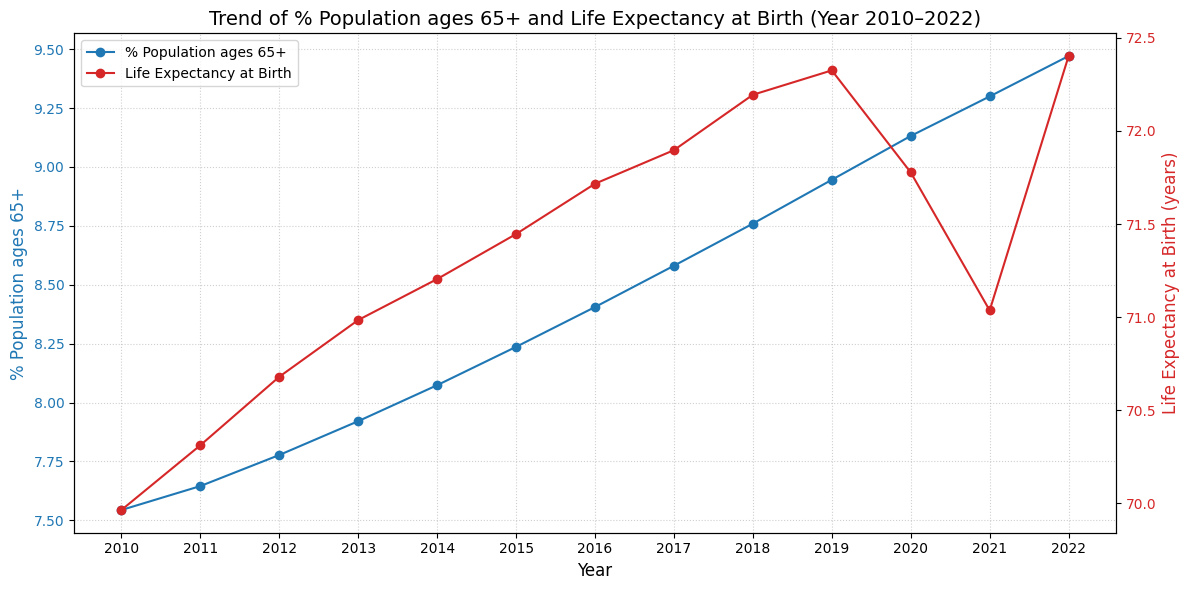

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the aging and life expectancy datasets
df_aging = pd.read_csv("/content/drive/My Drive/Use/aging _65_and_above.csv", encoding="ISO-8859-1")
df_life_expectancy = pd.read_csv("/content/drive/My Drive/Use/life_expectancy.csv", encoding="ISO-8859-1")

# Function to prepare aging and life expectancy data
def prepare_demographic_data(df, series_name_to_filter, value_name):
    """
    Cleans and reshapes a single dataframe from wide to long format for demographic data.
    """
    # Identify the year columns
    year_cols = [col for col in df.columns if '[YR' in col]

    # Define the columns that identify each unique entry
    id_vars = ['Country Name', 'Country Code', 'Series Name', 'Series Code']

    # Convert from 'wide' to 'long' format
    df_long = pd.melt(df, id_vars=id_vars, value_vars=year_cols, var_name='Year', value_name=value_name)

    # Extract the year and convert to integer
    df_long['Year'] = df_long['Year'].str.extract(r'(\d{4})').astype(int)

    # Filter for the specific metric
    df_filtered = df_long[df_long['Series Name'] == series_name_to_filter].copy()

    # Convert the value column to numeric, coercing errors to NaN
    df_filtered[value_name] = pd.to_numeric(df_filtered[value_name], errors='coerce')

    # Drop rows with missing values
    df_filtered.dropna(subset=[value_name], inplace=True)

    return df_filtered.drop(columns=['Series Name', 'Series Code'])

# Prepare the aging and life expectancy data
df_aging_clean = prepare_demographic_data(df_aging, 'Population ages 65 and above (% of total population)', 'Aging_Percentage')
df_life_expectancy_clean = prepare_demographic_data(df_life_expectancy, 'Life expectancy at birth, total (years)', 'Life_Expectancy')

# Filter data to include only countries present in OOP
countries_in_final_df = df_final['Country Code'].unique()
df_aging_filtered = df_aging_clean[df_aging_clean['Country Code'].isin(countries_in_final_df)].copy()
df_life_expectancy_filtered = df_life_expectancy_clean[df_life_expectancy_clean['Country Code'].isin(countries_in_final_df)].copy()

# Merge the aging and life expectancy data
df_demographics = pd.merge(df_aging_filtered, df_life_expectancy_filtered, on=['Country Name', 'Country Code', 'Year'], how='inner')

# Filter for the years 2010-2022
df_demographics_filtered_years = df_demographics[(df_demographics['Year'] >= 2010) & (df_demographics['Year'] <= 2022)].copy()

# Display the filtered demographics data
print("Filtered demographics data (2010-2022) for countries in df_final:")
display(df_demographics_filtered_years.head())

# Calculate the average for each year across the filtered countries
df_demographics_trend = df_demographics_filtered_years.groupby('Year')[['Aging_Percentage', 'Life_Expectancy']].mean().reset_index()

# Create the dual-axis plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Aging Percentage on the first y-axis
ax1.plot(df_demographics_trend['Year'], df_demographics_trend['Aging_Percentage'], marker='o', color='tab:blue', label='% Population ages 65+')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('% Population ages 65+', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.set_xticks(df_demographics_trend['Year']) # Ensure all years are shown on the x-axis

# Create the second y-axis
ax2 = ax1.twinx()

# Plot Life Expectancy on the second y-axis
ax2.plot(df_demographics_trend['Year'], df_demographics_trend['Life_Expectancy'], marker='o', color='tab:red', label='Life Expectancy at Birth')
ax2.set_ylabel('Life Expectancy at Birth (years)', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')

# Add title and legends
plt.title('Trend of % Population ages 65+ and Life Expectancy at Birth (Year 2010–2022)', fontsize=14)
fig.tight_layout() # Adjust layout to prevent overlapping
# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

### Trend of % Population ages 65+ and Life Expectancy at Birth: OECD vs Non-OECD (Year 2010-2022)


In [7]:
# Define the list of OECD country codes
oecd_countries = [
    "AUS", "AUT", "BEL", "CAN", "CHL", "COL", "CRI", "CZE", "DNK", "EST",
    "FIN", "FRA", "DEU", "GRC", "HUN", "ISL", "IRL", "ISR", "ITA", "JPN",
    "KOR", "LVA", "LTU", "LUX", "MEX", "NLD", "NZL", "NOR", "POL", "PRT",
    "SVK", "SVN", "ESP", "SWE", "CHE", "TUR", "GBR", "USA"
]

# Add 'OECD_Status' column to df_demographics_filtered_years
df_demographics_filtered_years['OECD_Status'] = df_demographics_filtered_years['Country Code'].apply(
    lambda x: 'OECD' if x in oecd_countries else 'Non-OECD'
)

# Display the counts of OECD vs Non-OECD countries to verify
print("Counts of OECD vs Non-OECD countries in the demographic data:")
print(df_demographics_filtered_years['OECD_Status'].value_counts())

Counts of OECD vs Non-OECD countries in the demographic data:
OECD_Status
Non-OECD    1937
OECD         494
Name: count, dtype: int64


Mean Aging Percentage and Life Expectancy by Year and OECD Status:


,Year,OECD_Status,Aging_Percentage,Life_Expectancy
0,2010,Non-OECD,5.697625,67.625267
1,2010,OECD,14.783764,79.135845
2,2011,Non-OECD,5.759737,67.963405
3,2011,OECD,15.040114,79.520972
4,2012,Non-OECD,5.842976,68.388805


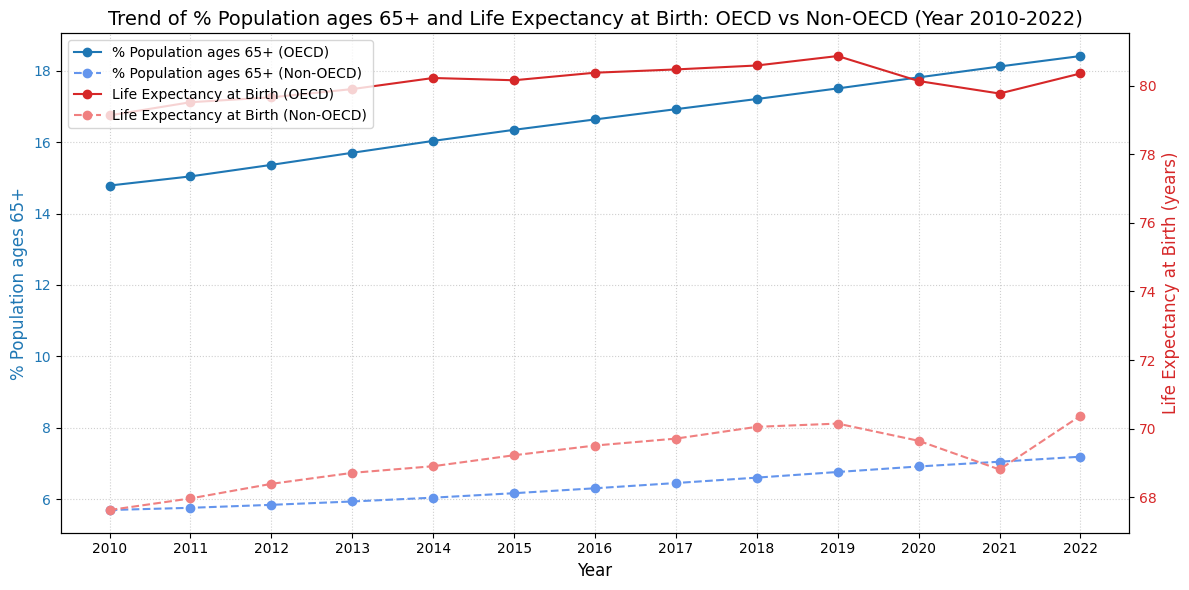

In [8]:
# Group by year and OECD_Status and calculate the mean for plotting the trend
df_demographics_oecd_trend = df_demographics_filtered_years.groupby(['Year', 'OECD_Status'])[['Aging_Percentage', 'Life_Expectancy']].mean().reset_index()

# Display the first few rows of the resulting DataFrame to verify
print("Mean Aging Percentage and Life Expectancy by Year and OECD Status:")
display(df_demographics_oecd_trend.head())

# Filter the data for OECD and Non-OECD
df_oecd_trend = df_demographics_oecd_trend[df_demographics_oecd_trend['OECD_Status'] == 'OECD'].copy()
df_non_oecd_trend = df_demographics_oecd_trend[df_demographics_oecd_trend['OECD_Status'] == 'Non-OECD'].copy()

# Create the dual-axis plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Aging Percentage on the first y-axis for both groups with specified styles
ax1.plot(df_oecd_trend['Year'], df_oecd_trend['Aging_Percentage'], marker='o', color='tab:blue', label='% Population ages 65+ (OECD)', linestyle='-') # Solid Blue
ax1.plot(df_non_oecd_trend['Year'], df_non_oecd_trend['Aging_Percentage'], marker='o', color='cornflowerblue', linestyle='--', label='% Population ages 65+ (Non-OECD)') # Dashed Light blue
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('% Population ages 65+', color='tab:blue', fontsize=12) # Keep axis label color consistent with OECD Aging for main axis
ax1.tick_params(axis='y', labelcolor='tab:blue') # Keep tick label color consistent with OECD Aging for main axis
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.set_xticks(df_demographics_oecd_trend['Year'].unique()) # Ensure all years are shown on the x-axis


# Create the second y-axis
ax2 = ax1.twinx()

# Plot Life Expectancy on the second y-axis for both groups with specified styles
ax2.plot(df_oecd_trend['Year'], df_oecd_trend['Life_Expectancy'], marker='o', color='tab:red', linestyle='-', label='Life Expectancy at Birth (OECD)') # Solid Red
ax2.plot(df_non_oecd_trend['Year'], df_non_oecd_trend['Life_Expectancy'], marker='o', color='lightcoral', linestyle='--', label='Life Expectancy at Birth (Non-OECD)') # Dashed Light red
ax2.set_ylabel('Life Expectancy at Birth (years)', color='tab:red', fontsize=12) # Keep axis label color consistent with OECD Aging for secondary axis
ax2.tick_params(axis='y', labelcolor='tab:red') # Keep tick label color consistent with OECD Aging for secondary axis


# Add title and legends
plt.title('Trend of % Population ages 65+ and Life Expectancy at Birth: OECD vs Non-OECD (Year 2010-2022)', fontsize=14)
fig.tight_layout() # Adjust layout to prevent overlapping
# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

### % Population ages 65+ vs Health Expenditure per Capita: OECD vs Non-OECD (Year 2022)

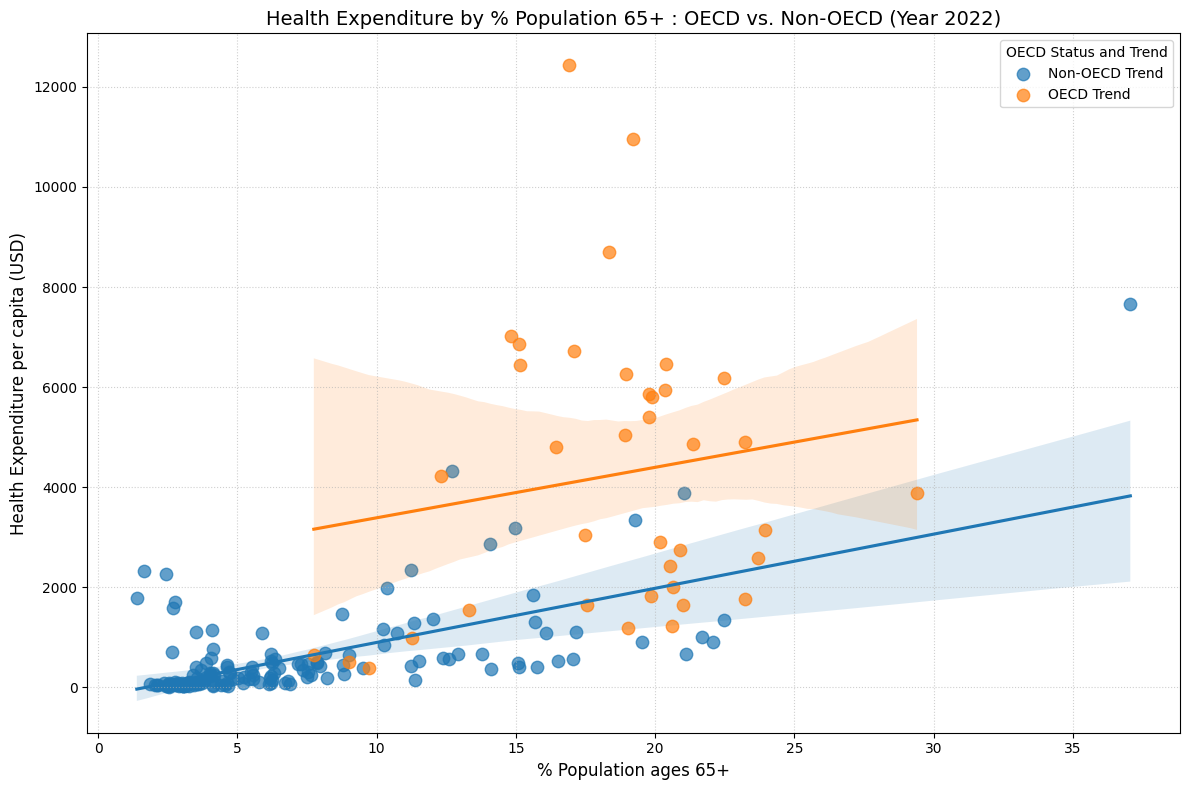

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Merge the demographic data with the health expenditure data
df_merged_demographics_health = pd.merge(
    df_demographics_filtered_years[['Country Code', 'Year', 'Aging_Percentage', 'OECD_Status']],
    df_health_clean[['Country Code', 'Year', 'Health_Expenditure_Value']],
    on=['Country Code', 'Year'],
    how='inner'
)

# Drop rows with missing values after merging
df_merged_demographics_health.dropna(inplace=True)

# Select the year 2022 for the scatter plot
year_to_analyze = 2022
df_year_scatter = df_merged_demographics_health[df_merged_demographics_health['Year'] == year_to_analyze].copy()

# Create the scatter plot with regression lines
plt.figure(figsize=(12, 8))

# Use seaborn.regplot to show scatter points and regression line with confidence interval
sns.regplot(data=df_year_scatter[df_year_scatter['OECD_Status'] == 'Non-OECD'], x='Aging_Percentage', y='Health_Expenditure_Value', color='tab:blue', label='Non-OECD Trend', scatter_kws={'s': 80, 'alpha': 0.7})
sns.regplot(data=df_year_scatter[df_year_scatter['OECD_Status'] == 'OECD'], x='Aging_Percentage', y='Health_Expenditure_Value', color='tab:orange', label='OECD Trend', scatter_kws={'s': 80, 'alpha': 0.7})

plt.title(f'Health Expenditure by % Population 65+ : OECD vs. Non-OECD (Year {year_to_analyze})', fontsize=14)
plt.xlabel('% Population ages 65+', fontsize=12)
plt.ylabel('Health Expenditure per capita (USD)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='OECD Status and Trend')
plt.tight_layout()
plt.show()

#**3. OECD Focus: Pharmaceutical Spending**

##Accumulated Pharmaceutical Expenditure as % of Total Health Expenditure (2010-2022) by Country

Preview of the merged pharmaceutical and health expenditure data (2010-2022):


,Country Name,Country Code,Year,Pharmaceutical_Expenditure_Value,Health_Expenditure_Value
0,United States,USA,2010,1146.495,7836.088379
1,Greece,GRC,2010,963.584,2564.369385
2,Canada,CAN,2010,911.490,5062.482910
3,France,FRA,2010,884.065,4592.383301
4,Germany,DEU,2010,870.773,4611.421875



Overall Mean Average Pharmaceutical Expenditure as % of Total Health Expenditure (2010-2022): 22.02%

Average Pharmaceutical Expenditure as % of Total Health Expenditure : OECD (Year 2010-2022)


,Country Name,Country Code,Pharmaceutical_Expenditure_Value,Health_Expenditure_Value,Average_Pharma_of_Total_HealthExp
14,Hungary,HUN,629.923923,1052.913617,59.826743
26,Poland,POL,453.681615,938.818322,48.324751
21,Lithuania,LTU,531.913000,1186.002991,44.849212
20,Latvia,LVA,463.876846,1044.971722,44.391330
23,Mexico,MEX,247.873154,564.915448,43.877921
13,Greece,GRC,726.748615,1796.145790,40.461561
5,Colombia,COL,194.547000,517.148981,37.619140
7,Czechia,CZE,558.854385,1732.452064,32.258000
9,Estonia,EST,408.501769,1410.228549,28.967061
4,Chile,CHL,375.921750,1435.988678,26.178601


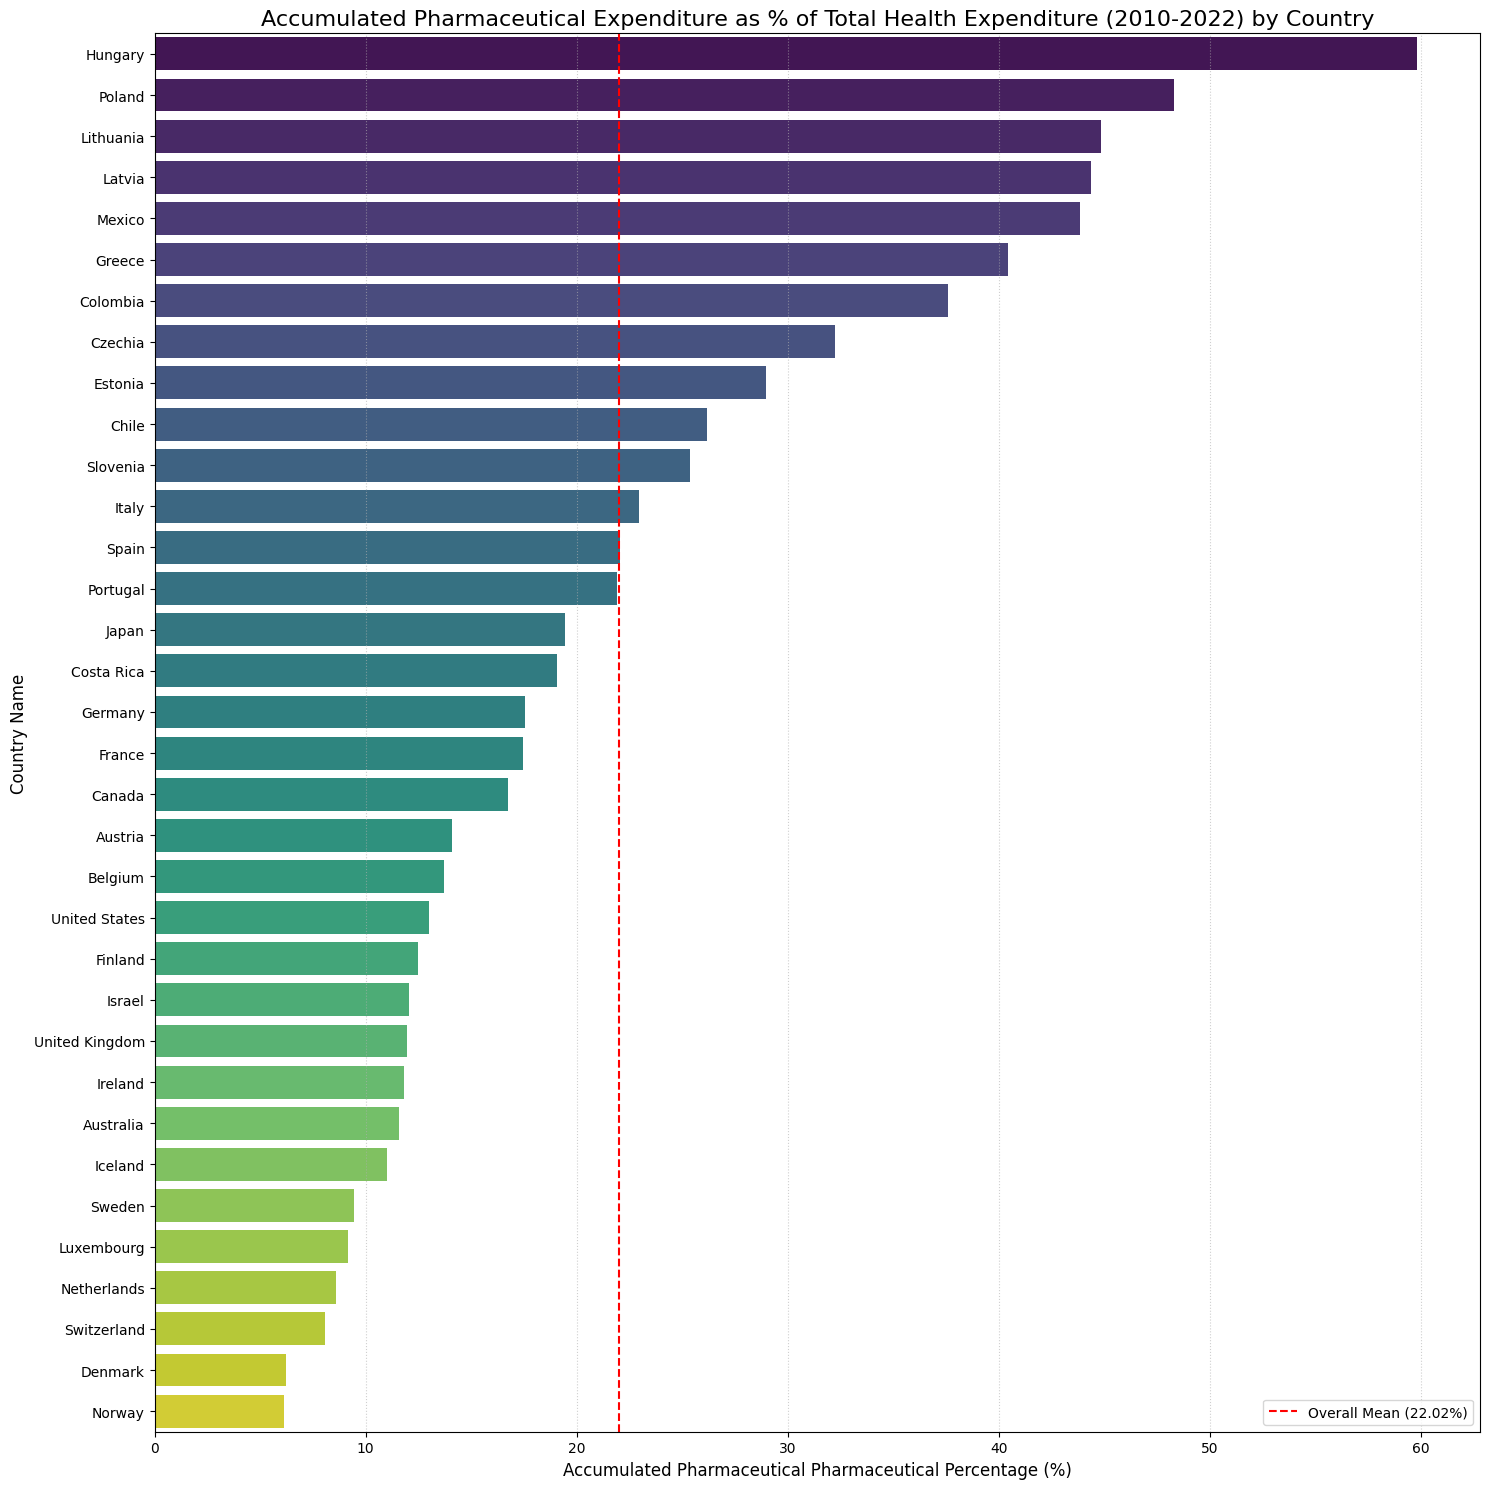

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

try:
    # Code from cell 2cdc34b3 to merge pharmaceutical and health expenditure data
    df_merged_pharm_health = pd.merge(
        df_pharm_clean,
        df_health_clean[['Country Code', 'Year', 'Country Name', 'Health_Expenditure_Value']],
        on=['Country Code', 'Year', 'Country Name'],
        how='inner'
    )

    # Filter for the years 2010-2022
    df_merged_pharm_health_filtered_years = df_merged_pharm_health[(df_merged_pharm_health['Year'] >= 2010) & (df_merged_pharm_health['Year'] <= 2022)].copy()

    # Drop rows with missing values after merging and filtering
    df_merged_pharm_health_filtered_years.dropna(inplace=True)

    print("Preview of the merged pharmaceutical and health expenditure data (2010-2022):")
    display(df_merged_pharm_health_filtered_years.head())

    # Calculate the average Pharmaceutical_Expenditure_Value and Health_Expenditure_Value over the years for each Country
    df_average_spending = df_merged_pharm_health_filtered_years.groupby(['Country Name', 'Country Code'])[['Pharmaceutical_Expenditure_Value', 'Health_Expenditure_Value']].mean().reset_index()


    # Calculate the average proportion of pharmaceutical spending as a percentage of total health expenditure
    # Use np.divide with where to avoid division by zero and assign 0 in those cases
    df_average_spending['Average_Pharma_of_Total_HealthExp'] = np.divide(
        df_average_spending['Pharmaceutical_Expenditure_Value'],
        df_average_spending['Health_Expenditure_Value'],
        out=np.zeros_like(df_average_spending['Pharmaceutical_Expenditure_Value']), # Use zeros_like for efficiency
        where=(df_average_spending['Health_Expenditure_Value'] != 0) # Condition to avoid division by zero
    ) * 100


    # Sort the data for better visualization
    df_average_spending_sorted = df_average_spending.sort_values('Average_Pharma_of_Total_HealthExp', ascending=False)

    # Calculate the overall mean average pharmaceutical expenditure percentage
    overall_mean_average_pharma_percentage = df_average_spending_sorted['Average_Pharma_of_Total_HealthExp'].mean()
    print(f"\nOverall Mean Average Pharmaceutical Expenditure as % of Total Health Expenditure (2010-2022): {overall_mean_average_pharma_percentage:.2f}%")


    # Display the average proportions (showing all countries)
    print("\nAverage Pharmaceutical Expenditure as % of Total Health Expenditure : OECD (Year 2010-2022)")
    display(df_average_spending_sorted) # Display all rows


    # Create a bar chart
    plt.figure(figsize=(15, 15)) # Adjusted figure size to be wider and potentially shorter

    # Use the full sorted DataFrame for plotting
    ax = sns.barplot(data=df_average_spending_sorted, x='Average_Pharma_of_Total_HealthExp', y='Country Name', palette='viridis', hue='Country Name', legend=False) # Use full data


    plt.title('Accumulated Pharmaceutical Expenditure as % of Total Health Expenditure (2010-2022) by Country', fontsize=16) # Updated title
    plt.xlabel('Accumulated Pharmaceutical Pharmaceutical Percentage (%)', fontsize=12)
    plt.ylabel('Country Name', fontsize=12)
    plt.grid(axis='x', linestyle=':', alpha=0.6)


    # Add a vertical benchmark line at the overall mean
    ax.axvline(overall_mean_average_pharma_percentage, color='red', linestyle='--', label=f'Overall Mean ({overall_mean_average_pharma_percentage:.2f}%)')

    # Add a legend for the benchmark line
    ax.legend(loc='lower right')


    plt.tight_layout() # Use tight_layout to adjust spacing
    plt.show()

except NameError:
    print("Error: Required DataFrames (df_pharm_clean, df_health_clean) not found. Please ensure previous cells are run.")

##Trend of % Population ages 65+ and Pharmaceutical Expenditure per Capita : OECD (2010-2022)

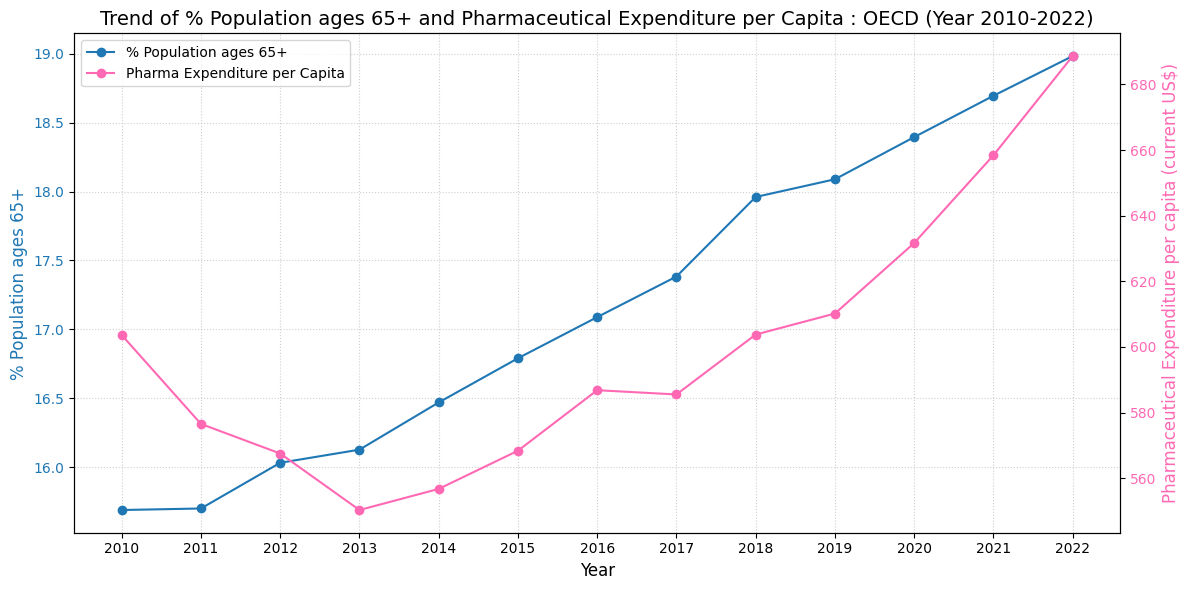

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the pharmaceutical expenditure dataset
df_pharm = pd.read_csv("/content/drive/My Drive/Use/pharm_expense_2010-2023.csv", encoding="ISO-8859-1")

# Function to prepare pharmaceutical expenditure data
def prepare_pharm_data(df, value_name):
    """
    Cleans and reshapes a single dataframe from wide to long format for pharmaceutical data.
    """

    # Rename the columns to a consistent format
    df_cleaned = df.rename(columns={'ï»¿Country Name': 'Country Name', 'US dollars/capita': value_name})

    # Convert the Year column to integer
    df_cleaned['Year'] = df_cleaned['Year'].astype(int)

    # Convert the value column to numeric, coercing errors to NaN
    df_cleaned[value_name] = pd.to_numeric(df_cleaned[value_name], errors='coerce')

    # Drop rows with missing values
    df_cleaned.dropna(subset=[value_name], inplace=True)

    # Filter for the years 2010-2022
    df_filtered_years = df_cleaned[(df_cleaned['Year'] >= 2010) & (df_cleaned['Year'] <= 2022)].copy()


    return df_filtered_years[['Country Name', 'Country Code', 'Year', value_name]]


# Prepare the pharmaceutical expenditure data
df_pharm_clean = prepare_pharm_data(df_pharm, 'Pharmaceutical_Expenditure_Value')


# Filter pharmaceutical data to include only countries present in df_demographics_filtered_years
countries_in_demographics_df = df_demographics_filtered_years['Country Code'].unique()
df_pharm_filtered = df_pharm_clean[df_pharm_clean['Country Code'].isin(countries_in_demographics_df)].copy()


# Merge the pharmaceutical data with the aging data
df_merged_pharm_aging = pd.merge(
    df_pharm_filtered,
    df_demographics_filtered_years[['Country Code', 'Year', 'Aging_Percentage', 'OECD_Status']],
    on=['Country Code', 'Year'],
    how='inner'
)

# Drop rows with missing values after merging
df_merged_pharm_aging.dropna(inplace=True)

# Calculate the average for each year across the merged countries
df_pharm_aging_trend = df_merged_pharm_aging.groupby('Year')[['Pharmaceutical_Expenditure_Value', 'Aging_Percentage']].mean().reset_index()

# Create the dual-axis plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Aging Percentage on the first y-axis
ax1.plot(df_pharm_aging_trend['Year'], df_pharm_aging_trend['Aging_Percentage'], marker='o', color='tab:blue', label='% Population ages 65+')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('% Population ages 65+', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.set_xticks(df_pharm_aging_trend['Year']) # Ensure all years are shown on the x-axis


# Create the second y-axis
ax2 = ax1.twinx()

# Plot Pharmaceutical Expenditure per capita on the second y-axis - Swapped with Aging Percentage
ax2.plot(df_pharm_aging_trend['Year'], df_pharm_aging_trend['Pharmaceutical_Expenditure_Value'], marker='o', color='hotpink', label='Pharma Expenditure per Capita')
ax2.set_ylabel('Pharmaceutical Expenditure per capita (current US$)', color='hotpink', fontsize=12)
ax2.tick_params(axis='y', labelcolor='hotpink')

# Add title and legends
plt.title('Trend of % Population ages 65+ and Pharmaceutical Expenditure per Capita : OECD (Year 2010-2022)', fontsize=14)
fig.tight_layout() # Adjust layout to prevent overlapping
# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

## Pharmaceutical Expenditure by % Population 65+ and GDP (Year 2022)

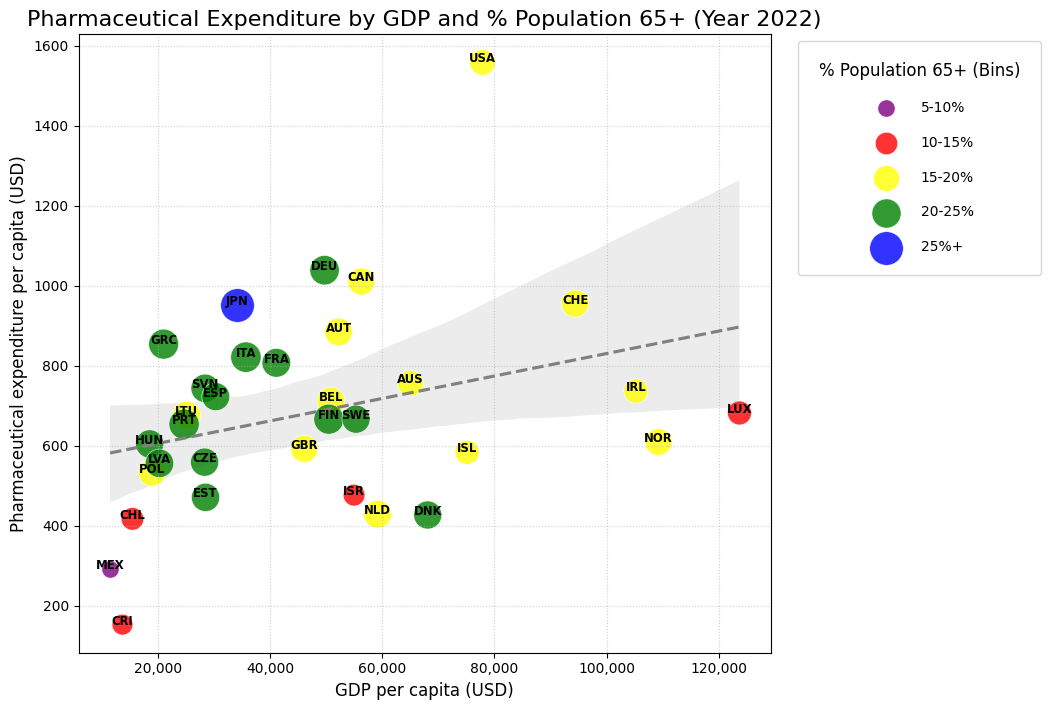

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


# Merge pharmaceutical data with GDP data
df_merged_pharm_gdp = pd.merge(
    df_pharm_clean,
    df_gdp_clean,
    on=['Country Name', 'Country Code', 'Year'],
    how='inner'
)

# Merge the result with aging data
df_merged_pharm_gdp_aging = pd.merge(
    df_merged_pharm_gdp,
    df_demographics_filtered_years[['Country Code', 'Year', 'Aging_Percentage', 'OECD_Status']],
    on=['Country Code', 'Year'],
    how='inner'
)

# Drop rows with missing values after merging
df_merged_pharm_gdp_aging.dropna(inplace=True)

# Select the year 2022 for the bubble plot
year_to_analyze = 2022
df_year_bubble = df_merged_pharm_gdp_aging[df_merged_pharm_gdp_aging['Year'] == year_to_analyze].copy()


# Define marker sizes based on Aging_Percentage (scale as needed for better visualization)
df_year_bubble['Bubble_Size'] = df_year_bubble['Aging_Percentage'] * 20

# Define bins for Aging_Percentage and assign colors
bins = [5, 10, 15, 20, 25, df_year_bubble['Aging_Percentage'].max()] # Adjusted bins
labels = ['5-10%', '10-15%', '15-20%', '20-25%', '25%+'] # Adjusted labels
colors = ['purple', 'red', 'yellow', 'green', 'blue'] # Adjusted colors

df_year_bubble['Aging_Color_Bin'] = pd.cut(df_year_bubble['Aging_Percentage'], bins=bins, labels=labels, right=True, include_lowest=True) # Changed right to True and include_lowest to True
color_map = dict(zip(labels, colors))


# Create the bubble chart
plt.figure(figsize=(16, 8))

# Add regression line
sns.regplot(
    data=df_year_bubble,
    x='GDP_Value',
    y='Pharmaceutical_Expenditure_Value',
    scatter=False, # Do not show scatter points here, only the line
    ci=95,
    color='gray', # Color for the regression line
    line_kws={'linestyle': '--'} # Make the line dashed
)


# Plot each bin separately to ensure correct coloring and legend
# Iterate through labels to maintain order
for label in labels:
    subset = df_year_bubble[df_year_bubble['Aging_Color_Bin'] == label]
    plt.scatter(subset['GDP_Value'], subset['Pharmaceutical_Expenditure_Value'],
                s=subset['Bubble_Size'], alpha=0.8, edgecolors='w', linewidths=0.5,
                color=color_map[label], label=label)


# Add country labels to each bubble
for line in range(0, df_year_bubble.shape[0]):
     plt.text(df_year_bubble['GDP_Value'].iloc[line], df_year_bubble['Pharmaceutical_Expenditure_Value'].iloc[line], df_year_bubble['Country Code'].iloc[line], horizontalalignment='center', size='small', color='black', weight='semibold')


plt.title(f'Pharmaceutical Expenditure by GDP and % Population 65+ (Year {year_to_analyze})', fontsize=16)
plt.xlabel('GDP per capita (USD)', fontsize=12)
plt.ylabel('Pharmaceutical expenditure per capita (USD)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:,.0f}'.format(y)))


# Add legend for color bins
plt.legend(title='% Population 65+ (Bins)', scatterpoints=1, frameon=True, labelspacing=1.5, handletextpad=1, columnspacing=1, loc='upper right', bbox_to_anchor=(1.4, 1), title_fontsize=12, borderpad=1.5, handlelength=3) # Increased bbox_to_anchor x value


plt.tight_layout(rect=[0, 0, 0.8, 0.9])
plt.show()